# Population-Level Disagreement Analysis (Single-Label)

This experiment evaluates population-level labeling variability
across independent annotators.

For each question (`qid`), we examine how different sources
assign wellness dimensions.

We compare two ensembles:

- Human annotators (sampled participants)
- LLM models (independent dimension generators)

## Entropy in Our Populational Evaluation Setting

In the population-wise experiment,  
we measure how much disagreement exists **across different sources**
(humans or LLM models) for the same question (`qid`).

For a fixed question $$ q $$:

Assume we sample $$ k = 5 $$ sources.

Each source assigns a Top-1 dimension label from the 8-dimension space.

---

### Step 1 — Construct the empirical distribution

Example:

Suppose the 5 sampled sources assign:

- Emotional  
- Emotional  
- Cognitive  
- Emotional  
- Cognitive  

This yields the empirical distribution:

$$
P = [0.6, 0.4, 0, 0, 0, 0, 0, 0]
$$

(3 Emotional, 2 Cognitive.)

---

### Step 2 — Compute normalized entropy

Population disagreement is measured by Shannon entropy:

$$
H(P)
=
- \sum_i P(i) \log_2 P(i)
$$

For this example:

$$
H(P)
=
- (0.6 \log_2 0.6 + 0.4 \log_2 0.4)
$$

$$
H(P) \approx 0.971
$$

To normalize entropy into the range $$[0,1]$$,
we divide by the maximum possible entropy:

$$
H_{\max} = \log_2 K
$$

where $$ K $$ is the number of possible dimensions.

Since we have 8 dimensions:

$$
H_{\max} = \log_2 8 = 3
$$

Thus normalized entropy is:

$$
H_{\text{norm}}
=
\frac{H(P)}{\log_2 8}
$$

$$
H_{\text{norm}}
=
\frac{0.971}{3}
\approx 0.324
$$

---

### Interpretation

- If all sources fully agree  
  → distribution is one-hot  
  → $$ H = 0 $$  
  → perfect population agreement  

- If sources split evenly across many dimensions  
  → distribution becomes more uniform  
  → entropy increases  
  → greater population-level disagreement  

The theoretical maximum occurs when all 8 dimensions
are equally likely:

$$
P = [\tfrac{1}{8}, \dots, \tfrac{1}{8}]
$$

which yields:

$$
H_{\text{norm}} = 1
$$

---

### Repeated Sampling

Because the number of sources differs between human and LLM,
we downsample to a fixed $$ k $$ sources per run.

For each run:

$$
\text{RunScore}
=
\frac{1}{|\mathcal{Q}|}
\sum_{q \in \mathcal{Q}}
H_{\text{norm}}(q)
$$

We repeat this sampling multiple times and report:

- Mean
- Median
- Percentiles

This provides a stable estimate of population-level disagreement.

In [1]:
from pathlib import Path
from mhdr.dataloader.io import read_csv, save_csv
INPUT_DIR = Path.cwd() / "input"
OUTPUT_DIR = Path.cwd() / "output"
TEMP_DIR = Path.cwd() / "temp"
QUESTION_DATA = read_csv(INPUT_DIR / "none_dup_questions.csv")
HUMAN_DATA = read_csv(INPUT_DIR / "human_none_dup.csv")

# 1. Generating LLM-Based Dimension Assignments

We first obtain model-based labels for each question.

Procedure:

- Encode all questions using a fixed embedding model.
- For each LLM-generated dimension definition set:
  - Compute cosine similarity between question embeddings and dimension embeddings.
  - Assign dimensions using a margin-based selection rule (delta threshold).
- Extract the top-1 dimension per question.

Each LLM acts as an independent "annotator".

The result is a dataset of:

(qid, question text, assigned dimension, source model)

This forms the LLM annotation ensemble.

In [2]:
from mhdr.model.semantic_mapper import SemanticMapper
from mhdr.model.LLMio import load_dimension_sets
import pandas as pd
dimension_sets = load_dimension_sets(INPUT_DIR / "dim_definations.csv")

deltas = [0.05]

# 1) init once
mapper = SemanticMapper()
mapper.set_questions_df(QUESTION_DATA, text_col="text")
all_mapped = mapper.map_to_llm_dimension_definitions(
    dimension_sets,
    deltas=deltas,
)

exact_top1 = mapper.extract_top1_from_mapped(all_mapped, text_col='text')
save_csv(exact_top1, TEMP_DIR / f"llm_dup.csv")

# 3) sanity checks
print("\nMerged shape:", exact_top1.shape)
print("Unique models:", exact_top1["source"].unique())
print("Unique dimensions:", exact_top1["answer"].nunique())

/Users/haikeyu/Desktop/mentalhealth-dimension-reduction/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1303.89it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== Mapping using ChatGPT-5.2 ===

=== Mapping using DeepSeek-V3.2 ===

=== Mapping using Llama-4 ===

=== Mapping using claude-sonnet-4.5 ===

=== Mapping using gemini-3.0-pro ===

Merged shape: (390, 4)
Unique models: <StringArray>
[      'ChatGPT-5.2',     'DeepSeek-V3.2',           'Llama-4',
 'claude-sonnet-4.5',    'gemini-3.0-pro']
Length: 5, dtype: str
Unique dimensions: 8


# 2. Sampling-Based Population-Level Evaluation

To ensure fair comparison between humans and models,
we apply a controlled sampling strategy.

For each run:

- Randomly sample k human annotators.
- Sample k LLM models (fixed ensemble of 5 in this setup).
- For each question (qid):
  - Compute the label distribution across sampled sources.
  - Calculate normalized entropy as a measure of disagreement.
- Average entropy across all questions.

We repeat this process 100 times to estimate sampling variability.

Interpretation:

- Entropy = 0 → perfect agreement.
- Entropy = 1 → maximum disagreement.

Because the LLM ensemble size equals k (5 models),
LLM entropy remains constant across runs.
Human entropy varies due to sampling.

This allows us to compare:

Human population variability  
vs  
Cross-model variability

In [3]:
from mhdr.evaluator.populational_evaluator import PopulationalEvaluator

ev = PopulationalEvaluator(HUMAN_DATA, exact_top1)

(h_runs, h_sum, _), (l_runs, l_sum, _) = ev.compare_human_vs_llm(
    k_sources=3,   # human sampled to 5, llm sampled to 5 (if llm exactly 5 -> full set)
    times=100,
    seed=42,
    qid_col="qid",
    source_col="source",
    label_col="answer",
)

print(h_sum)
print(l_sum)

   which  k_sources  times      mean    median       p10       p90
0  human          3    100  0.196738  0.182192  0.135344  0.307127
  which  k_sources  times      mean    median       p10       p90
0   llm          3    100  0.187227  0.187614  0.159446  0.217934


# 3. Visualization of Population-Level Disagreement

We visualize the entropy scores across 100 sampling runs.

The plot shows:

- Human entropy per run (sampling 5 participants)
- LLM entropy per run (fixed ensemble of 5 models)
- Mean entropy for both groups

Key observations:

- Human entropy varies across runs due to random sampling.
- LLM entropy remains constant because the full model ensemble
  is used in every run.
- The mean entropy of humans and LLMs is nearly identical.

This indicates that cross-model disagreement is comparable
to cross-human disagreement at k=5 sources.

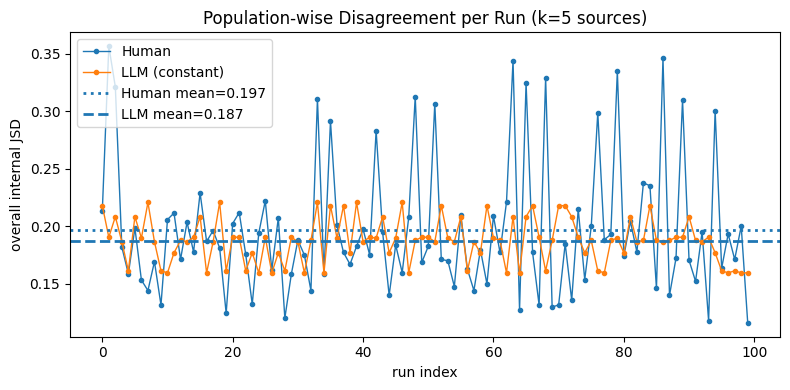

In [4]:
import matplotlib.pyplot as plt
import numpy as np

overall_col = "overall_entropy"

hr = h_runs.sort_values("run")[overall_col].to_numpy()
lr = l_runs.sort_values("run")[overall_col].to_numpy()

x = np.arange(len(hr))

plt.figure(figsize=(8,4))
plt.plot(x, hr, marker="o", linewidth=1, markersize=3, label="Human")
plt.plot(x, lr, marker="o", linewidth=1, markersize=3, label="LLM (constant)")
plt.axhline(np.mean(hr), linestyle=":", linewidth=2, label=f"Human mean={np.mean(hr):.3f}")
plt.axhline(np.mean(lr), linestyle="--", linewidth=2, label=f"LLM mean={np.mean(lr):.3f}")
plt.title("Population-wise Disagreement per Run (k=5 sources)")
plt.xlabel("run index")
plt.ylabel("overall internal JSD")
plt.legend()
plt.tight_layout()
plt.show()